In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import os

In [14]:
datasets = [file for file in os.listdir("../../datasets/synthetic/") if "csv" in file]

model = 'RandomForestClassifier'
dataset = 'sine_unbalanced.csv'

# filename_mtl = f'../metabases/basemodel: {model} - dataset: {dataset} - with_drift_metrics.csv'
# results = pd.read_csv(filename_mtl)
# results['original_idx'].unique()

# filename_mtl = f'../metabases/basemodel: {model} - dataset: {dataset} - with_drift_metrics.csv'
# results = pd.read_csv(filename_mtl)
# concept = get_concept(results['original_idx'], dataset)
# results['concept'] = concept
# results


In [15]:
def get_concept(original_idx: pd.Series, dataset: str, concept_type="last"):
    """Read the original dataframe to recover the context

    Args:
        original_idx (pd.Series): maps the metabase indexes to the original base indexes (before windowing)
        dataset (str): dataset name to be loaded
        concept_type (str, optional): how to set the window concept, it can be:
            - "last": The last concept of the batch
            - "most_frequent": The most frequent concept of the batch
    """
    filename_concept = f'../../datasets/synthetic/{dataset}'
    df_concept = pd.read_csv(filename_concept)['concept']

    concepts = []
    for idx in original_idx:
        bounds = [int(bound) for bound in idx.split(':')]
        concept_batch = df_concept[bounds[0]:bounds[1]]
        
        if concept_type == "last":
            concepts.append(concept_batch.values[-1])
        else:
            most_frequent_concept = concept_batch.value_counts().idxmax()
            concepts.append(most_frequent_concept)
    return concepts

In [16]:
def load_data(dataset, model, concept_type="last"):
    filename_mtl = f'../metabases/basemodel: {model} - dataset: {dataset} - with_drift_metrics.csv'
    results = pd.read_csv(filename_mtl)
    concept = get_concept(results['original_idx'], dataset, concept_type)
    results['concept'] = concept
    return results

def plot_concepts(dataset, ax):
    concepts = dataset.drop_duplicates(subset='concept', keep='first')
    concepts = concepts.reset_index()[['concept', 'index']]
    for _, concept in concepts.iterrows():
        ax.axvline(x=concept['index'], color='r', linestyle='--')

def plot_data(model, concept_type="last"):
    _, axs = plt.subplots(len(datasets), 4, figsize=(20, 3*len(datasets)))
    try:
        for row, dataset in enumerate(datasets):
            df = load_data(dataset, model, concept_type)
            for col, metric in enumerate(["kappa", "precision", "recall", "f1-score"]):
                ax = axs[row, col]
                df.plot(y=[metric, f'predicted_{metric}', f'last_{metric}'], ax=ax, title=dataset[:-4])
                plot_concepts(df, ax)
    except:
        print(f'error dataset {dataset}')

error dataset gradual_friedman.csv


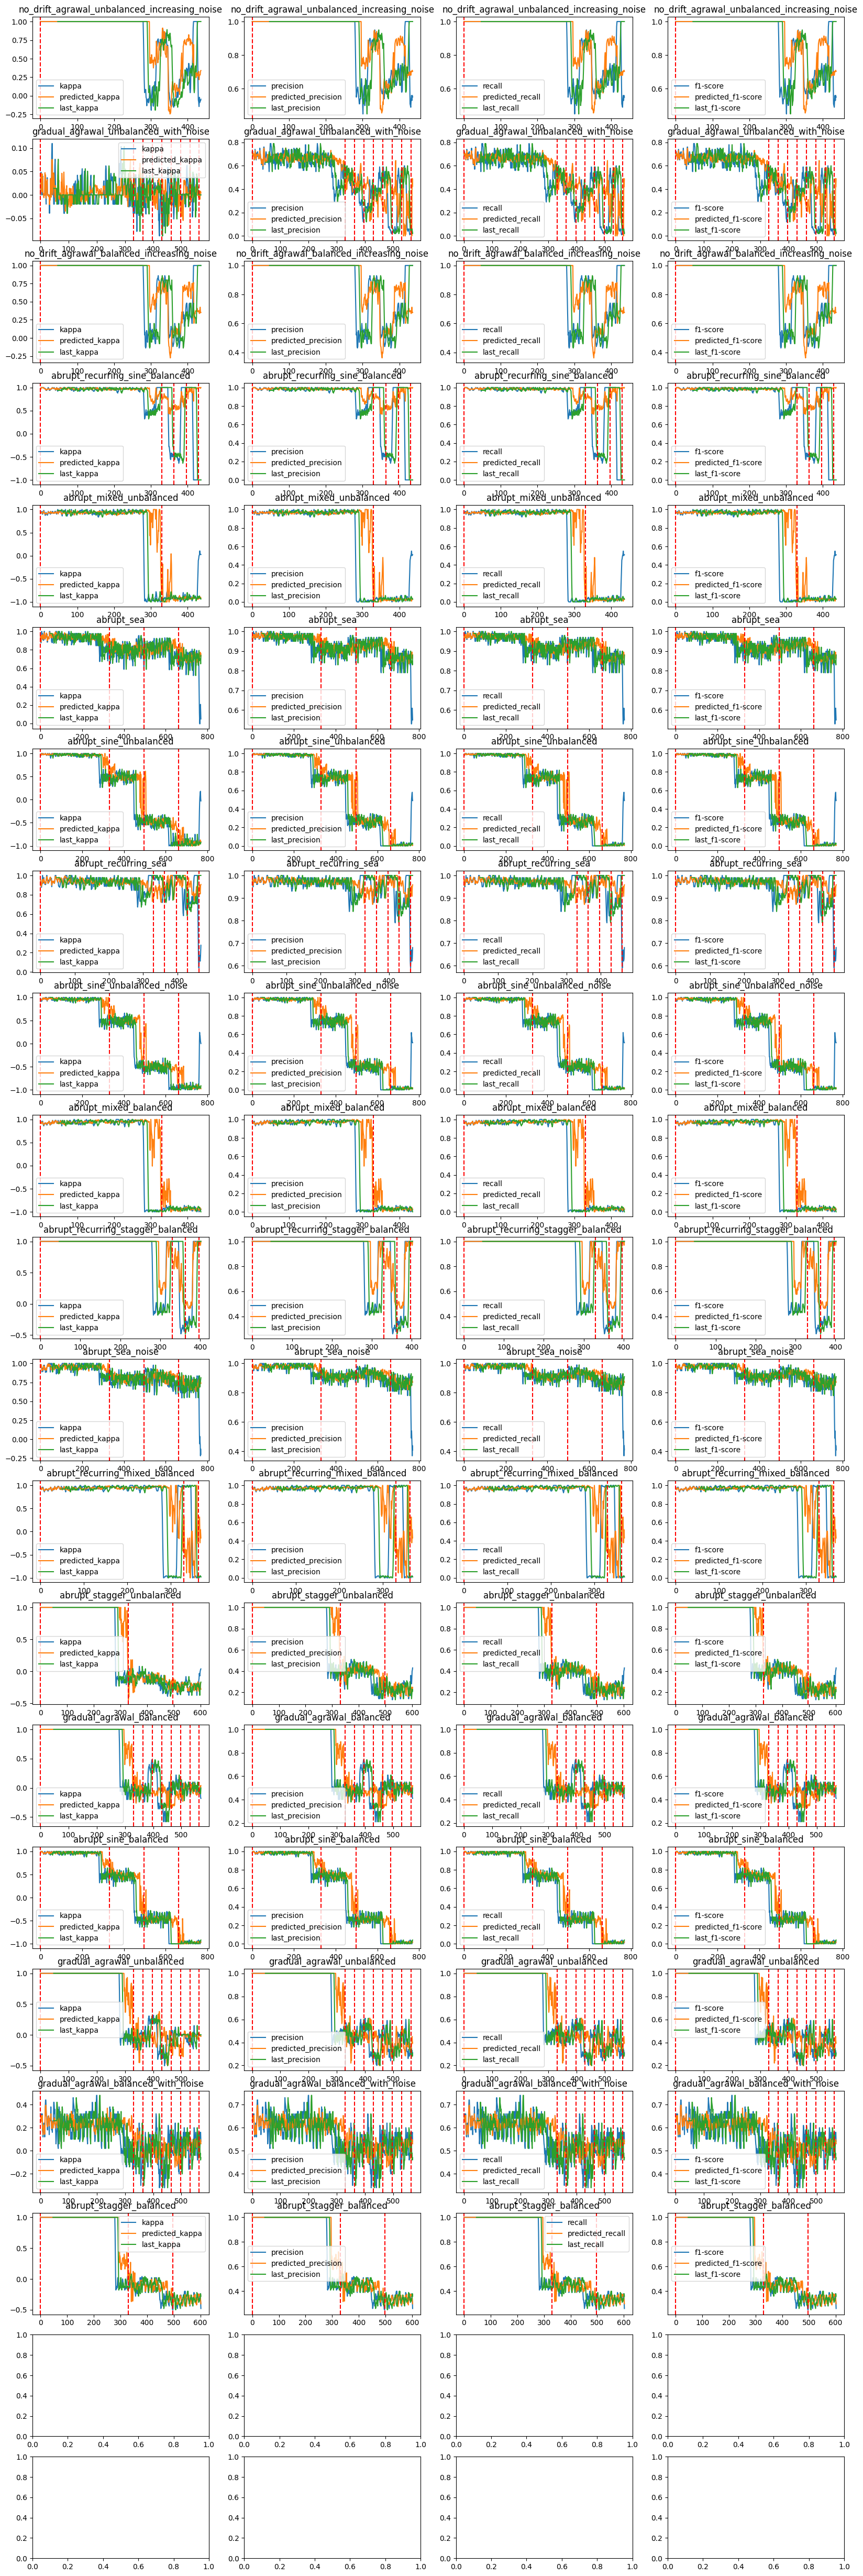

In [17]:
plot_data('RandomForestClassifier')

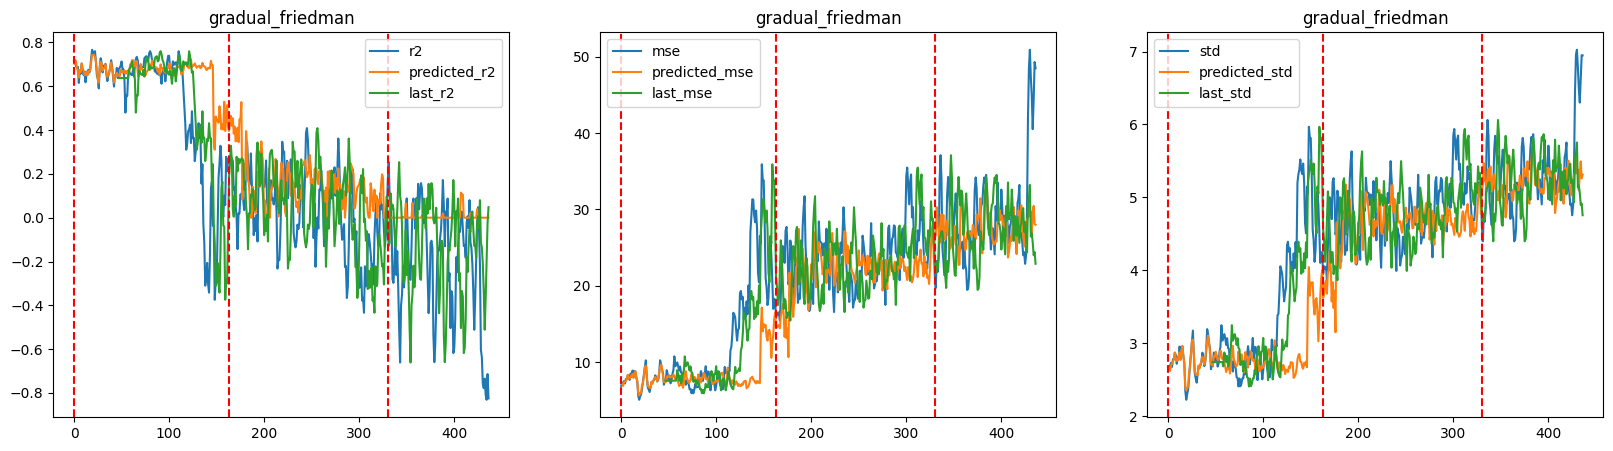

In [18]:
reg_dataset = 'gradual_friedman.csv'

def plot_regression_data(model):
    _, axs = plt.subplots(1, 3, figsize=(20, 5))
    df = load_data(reg_dataset, model)
    for col, metric in enumerate(["r2", "mse", "std"]):
        ax = axs[col]
        df.plot(y=[metric, f'predicted_{metric}', f'last_{metric}'], ax=ax, title=reg_dataset[:-4])
        plot_concepts(df, ax)

plot_regression_data('DecisionTreeRegressor')

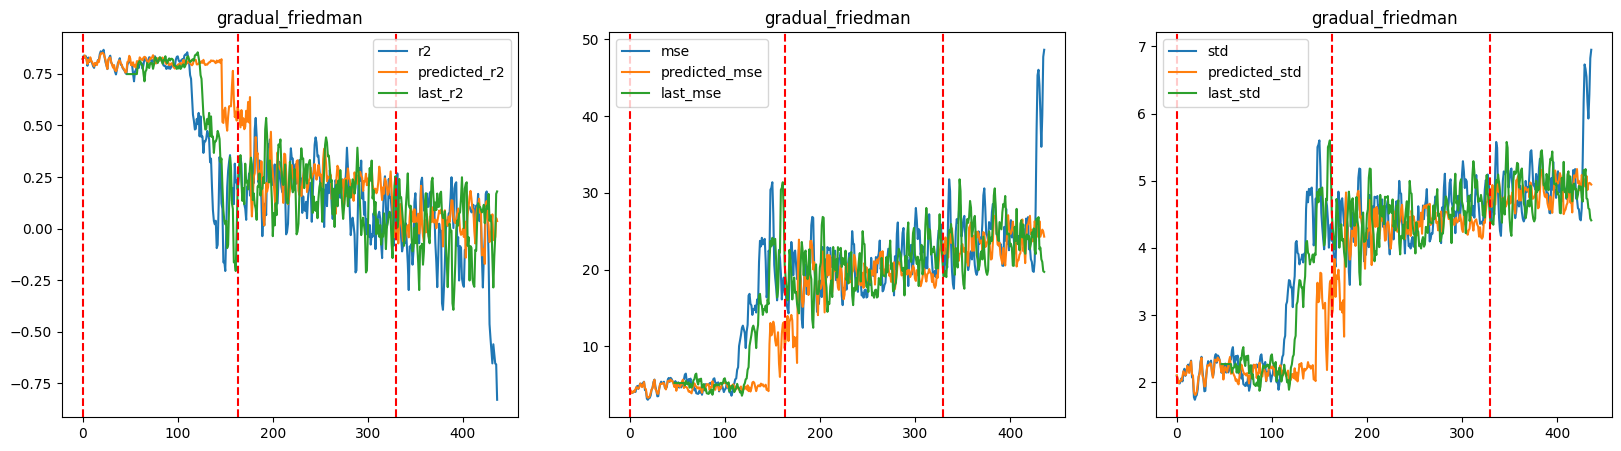

In [19]:
plot_regression_data('RandomForestRegressor')